In [60]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

In [61]:
df = pd.read_csv("StudentPerformanceFactors.csv")
print(f"Rows, Columns: {df.shape}\n")

Rows, Columns: (6607, 20)



In [62]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6607 entries, 0 to 6606
Data columns (total 20 columns):
 #   Column                      Non-Null Count  Dtype 
---  ------                      --------------  ----- 
 0   Hours_Studied               6607 non-null   int64 
 1   Attendance                  6607 non-null   int64 
 2   Parental_Involvement        6607 non-null   object
 3   Access_to_Resources         6607 non-null   object
 4   Extracurricular_Activities  6607 non-null   object
 5   Sleep_Hours                 6607 non-null   int64 
 6   Previous_Scores             6607 non-null   int64 
 7   Motivation_Level            6607 non-null   object
 8   Internet_Access             6607 non-null   object
 9   Tutoring_Sessions           6607 non-null   int64 
 10  Family_Income               6607 non-null   object
 11  Teacher_Quality             6529 non-null   object
 12  School_Type                 6607 non-null   object
 13  Peer_Influence              6607 non-null   obje

,Hours_Studied,Attendance,Sleep_Hours,Previous_Scores,Tutoring_Sessions,Physical_Activity,Exam_Score
count,6607.000000,6607.000000,6607.00000,6607.000000,6607.000000,6607.000000,6607.000000
mean,19.975329,79.977448,7.02906,75.070531,1.493719,2.967610,67.235659
std,5.990594,11.547475,1.46812,14.399784,1.230570,1.031231,3.890456
min,1.000000,60.000000,4.00000,50.000000,0.000000,0.000000,55.000000
25%,16.000000,70.000000,6.00000,63.000000,1.000000,2.000000,65.000000
50%,20.000000,80.000000,7.00000,75.000000,1.000000,3.000000,67.000000
75%,24.000000,90.000000,8.00000,88.000000,2.000000,4.000000,69.000000
max,44.000000,100.000000,10.00000,100.000000,8.000000,6.000000,101.000000


In [63]:

features = ["Hours_Studied", "Attendance", "Sleep_Hours" ,"Previous_Scores" ,"Physical_Activity"]
target = "Exam_Score"
X=df[features]
y = df[target]


In [64]:
X = X.fillna(X.mean())
y = y.fillna(y.mean())


In [65]:
# Split Data into training and testing sets
X_train, X_test, y_train ,y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [66]:
# Train with the mulitple linear regression Model
model =LinearRegression()
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [67]:
#model Coefficeints and intercep
print("Intercept: ", model.intercept_)
coeff_df=pd.DataFrame({
    "Coefficient" :model.coef_,
    "Feature" :X.columns
})
coeff_df

Intercept:  41.79674975704092


,Coefficient,Feature
0,0.287341,Hours_Studied
1,0.199262,Attendance
2,-0.037653,Sleep_Hours
3,0.047472,Previous_Scores
4,0.157120,Physical_Activity


In [68]:
#make predication
y_pred = model.predict(X_test)

In [69]:
# Evaluate Model PErformance
mse = mean_squared_error(y_test, y_pred)
r2=r2_score(y_test, y_pred)
print("Mean Squared Error(MSE): ", mse)
print("R2 Score: ", r2)


Mean Squared Error(MSE):  5.324829707898493
R2 Score:  0.6232895361485649


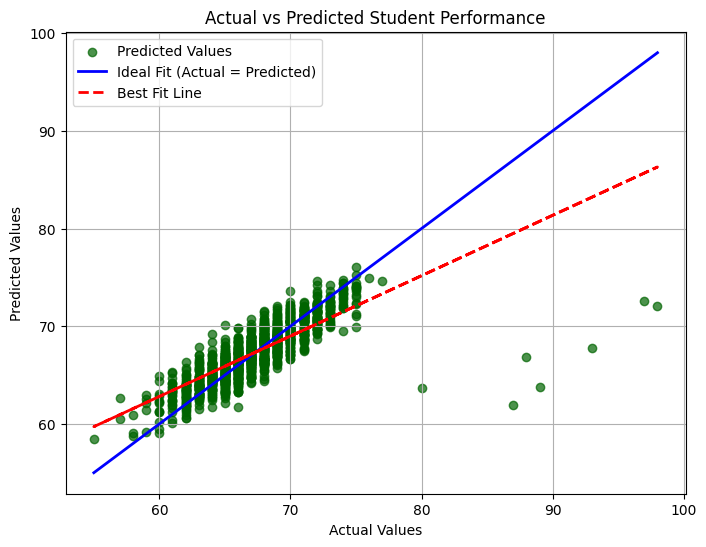

In [72]:
plt.figure(figsize=(8, 6))

# Scatter plot for predicted values
plt.scatter(
    y_test,
    y_pred,
    color='darkgreen',
    label='Predicted Values',
    alpha=0.7
)

# Ideal line (Actual = Predicted)
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color='blue',
    linewidth=2,
    label='Ideal Fit (Actual = Predicted)'
)
# Best-fit line using linear regression on y_test vs y_pred
m, b = np.polyfit(y_test, y_pred, 1)

plt.plot(
    y_test,
    m * y_test + b,
    linewidth=2,
    color='red',
    linestyle='dashed',
    label="Best Fit Line"
)
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs Predicted Student Performance")
plt.legend()
plt.grid(True)

plt.show()


In [71]:
 n#observation
print(
    "The scatter plot shows a positive correlation between actual and predicted values, "
    "indicating that the Multiple Linear Regression model performs reasonably well.\n"
)
#
print(
    "Multiple Linear Regression was successfully implemented to predict student performance "
    "using study hours, attendance, and assignment scores. "
    "The model performance was evaluated using Mean Squared Error and R² score, "
    "demonstrating effective prediction capability."
)


The scatter plot shows a positive correlation between actual and predicted values, indicating that the Multiple Linear Regression model performs reasonably well.

Multiple Linear Regression was successfully implemented to predict student performance using study hours, attendance, and assignment scores. The model performance was evaluated using Mean Squared Error and R² score, demonstrating effective prediction capability.


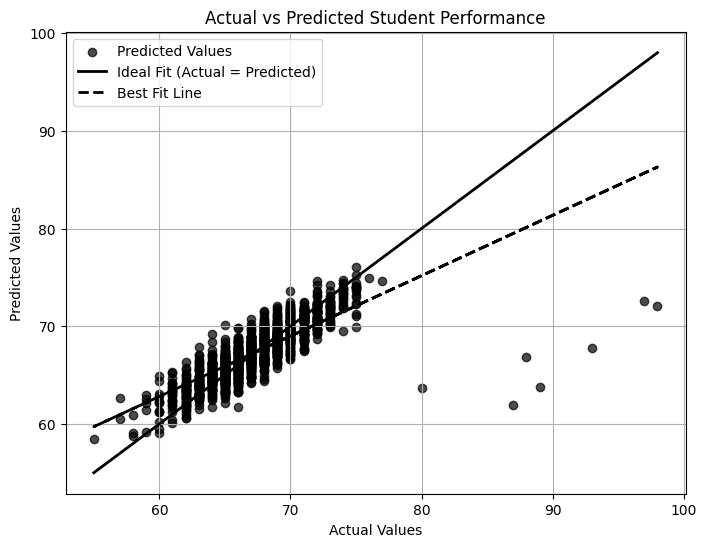

In [77]:
plt.figure(figsize=(8, 6))

# Scatter plot for predicted values
plt.scatter(
    y_test,
    y_pred,
    color='black',
    label='Predicted Values',
    alpha=0.7
)

# Ideal line (Actual = Predicted)
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color='black',
    linewidth=2,

    label='Ideal Fit (Actual = Predicted)'
)
# Best-fit line using linear regression on y_test vs y_pred
m, b = np.polyfit(y_test, y_pred, 1)

plt.plot(
    y_test,
    m * y_test + b,
    linewidth=2,
 color='black',
    linestyle='dashed',
    label="Best Fit Line"
)
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs Predicted Student Performance")
plt.legend()
plt.grid(True)

plt.show()
